# **Basic**

**MAGIC COMMANDS**

In [1]:
%who

Interactive namespace is empty.


In [2]:
i = 10

In [3]:
%who

i	 


In [4]:
%quickref

**PANDAS**

In [8]:
import pandas as pd

#Create Data
myData = {'people': ['Jen','Alex','Ben'], 'years': ['1','2','12']}

#Converting it to DataFrame
Frame = pd.DataFrame(myData)
print(Frame)
Frame

  people years
0    Jen     1
1   Alex     2
2    Ben    12


,people,years
0,Jen,1
1,Alex,2
2,Ben,12


In [12]:
df = pd.read_csv("/content/smallDataset.txt",parse_dates=["date"])
status_order = ["Healthy","Warning","Critical"]
df['health_status'] = pd.Categorical(df["health_status"], categories = status_order, ordered=True)

In [14]:
display(df.head())

,date,hostname,os,uptime_hours,adobe_runtime_minutes,cpu_usage_percent,memory_usage_percent,disk_free_gb,health_status,ticket_opened
0,2025-10-04,WS-001,Windows 10,19.78,199.1,49.2,75.2,153.5,Warning,False
1,2025-10-05,WS-001,Windows 10,20.95,23.2,59.3,71.3,78.1,Healthy,False
2,2025-10-06,WS-001,Windows 10,21.14,135.5,34.4,12.2,149.6,Healthy,False
3,2025-10-07,WS-001,Windows 10,23.20,333.6,50.9,57.4,158.8,Healthy,False
4,2025-10-08,WS-001,Windows 10,20.80,236.8,49.4,42.3,118.3,Healthy,False


In [15]:
df.info(memory_usage="deep")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   date                   300 non-null    datetime64[ns]
 1   hostname               300 non-null    object        
 2   os                     300 non-null    object        
 3   uptime_hours           300 non-null    float64       
 4   adobe_runtime_minutes  300 non-null    float64       
 5   cpu_usage_percent      300 non-null    float64       
 6   memory_usage_percent   300 non-null    float64       
 7   disk_free_gb           300 non-null    float64       
 8   health_status          300 non-null    category      
 9   ticket_opened          300 non-null    bool          
dtypes: bool(1), category(1), datetime64[ns](1), float64(5), object(2)
memory usage: 48.4 KB


In [17]:
df.dtypes

,0
date,datetime64[ns]
hostname,object
os,object
uptime_hours,float64
adobe_runtime_minutes,float64
cpu_usage_percent,float64
memory_usage_percent,float64
disk_free_gb,float64
health_status,category
ticket_opened,bool


In [18]:
df.isna().sum()

,0
date,0
hostname,0
os,0
uptime_hours,0
adobe_runtime_minutes,0
cpu_usage_percent,0
memory_usage_percent,0
disk_free_gb,0
health_status,0
ticket_opened,0


In [19]:
df.describe()

,date,uptime_hours,adobe_runtime_minutes,cpu_usage_percent,memory_usage_percent,disk_free_gb
count,300,300.000000,300.000000,300.000000,300.000000,300.000000
mean,2025-10-18 12:00:00,21.862033,183.047667,45.492667,55.264333,205.932667
min,2025-10-04 00:00:00,15.520000,6.700000,1.200000,1.900000,10.000000
25%,2025-10-11 00:00:00,20.635000,142.525000,35.175000,41.075000,152.275000
50%,2025-10-18 12:00:00,22.090000,180.350000,45.150000,54.950000,208.900000
75%,2025-10-26 00:00:00,23.380000,224.400000,54.550000,69.250000,250.275000
max,2025-11-02 00:00:00,24.000000,334.800000,95.600000,100.000000,455.400000
std,NaN,1.765123,59.714554,15.874845,18.829399,80.908691


In [20]:
df.select_dtypes(include=['number']).describe()

,uptime_hours,adobe_runtime_minutes,cpu_usage_percent,memory_usage_percent,disk_free_gb
count,300.000000,300.000000,300.000000,300.000000,300.000000
mean,21.862033,183.047667,45.492667,55.264333,205.932667
std,1.765123,59.714554,15.874845,18.829399,80.908691
min,15.520000,6.700000,1.200000,1.900000,10.000000
25%,20.635000,142.525000,35.175000,41.075000,152.275000
50%,22.090000,180.350000,45.150000,54.950000,208.900000
75%,23.380000,224.400000,54.550000,69.250000,250.275000
max,24.000000,334.800000,95.600000,100.000000,455.400000


In [23]:
df['health_status'].value_counts().reindex(df['health_status'].cat.categories)

,count
Healthy,236
Warning,42
Critical,22


In [24]:
df['date'].min(),df["date"].max()

(Timestamp('2025-10-04 00:00:00'), Timestamp('2025-11-02 00:00:00'))

In [27]:
df[['cpu_usage_percent','memory_usage_percent','disk_free_gb']].agg(["min","max"])

,cpu_usage_percent,memory_usage_percent,disk_free_gb
min,1.2,1.9,10.0
max,95.6,100.0,455.4


In [28]:
print(df["cpu_usage_percent"].head())

0    49.2
1    59.3
2    34.4
3    50.9
4    49.4
Name: cpu_usage_percent, dtype: float64


In [29]:
print(df[["hostname","date","cpu_usage_percent"]].head())

  hostname       date  cpu_usage_percent
0   WS-001 2025-10-04               49.2
1   WS-001 2025-10-05               59.3
2   WS-001 2025-10-06               34.4
3   WS-001 2025-10-07               50.9
4   WS-001 2025-10-08               49.4


In [30]:
print(df.iloc[0]) #shows the first row of the data

date                     2025-10-04 00:00:00
hostname                              WS-001
os                                Windows 10
uptime_hours                           19.78
adobe_runtime_minutes                  199.1
cpu_usage_percent                       49.2
memory_usage_percent                    75.2
disk_free_gb                           153.5
health_status                        Warning
ticket_opened                          False
Name: 0, dtype: object


In [31]:
is_critical = df["health_status"] == "Critical"
print(df.loc[is_critical,["date","hostname","health_status","cpu_usage_percent"]].head())
#it gives a quick glimse at the data you need to see

         date hostname health_status  cpu_usage_percent
6  2025-10-10   WS-001      Critical               86.7
8  2025-10-12   WS-001      Critical               28.0
40 2025-10-14   WS-002      Critical               52.7
43 2025-10-17   WS-002      Critical               61.3
53 2025-10-27   WS-002      Critical               26.4


In [33]:
high_cpu = df["cpu_usage_percent"] >= 80
print(df.loc[is_critical & high_cpu,["date","hostname","health_status","cpu_usage_percent"]].head())

          date hostname health_status  cpu_usage_percent
6   2025-10-10   WS-001      Critical               86.7
237 2025-10-31   WS-008      Critical               82.4


.loc = used for positions <br>
.iloc = used for integer positions

In [34]:
display(df.iloc[:5]) #shows first 5 rows

,date,hostname,os,uptime_hours,adobe_runtime_minutes,cpu_usage_percent,memory_usage_percent,disk_free_gb,health_status,ticket_opened
0,2025-10-04,WS-001,Windows 10,19.78,199.1,49.2,75.2,153.5,Warning,False
1,2025-10-05,WS-001,Windows 10,20.95,23.2,59.3,71.3,78.1,Healthy,False
2,2025-10-06,WS-001,Windows 10,21.14,135.5,34.4,12.2,149.6,Healthy,False
3,2025-10-07,WS-001,Windows 10,23.20,333.6,50.9,57.4,158.8,Healthy,False
4,2025-10-08,WS-001,Windows 10,20.80,236.8,49.4,42.3,118.3,Healthy,False


In [35]:
display(df.iloc[250:255])

,date,hostname,os,uptime_hours,adobe_runtime_minutes,cpu_usage_percent,memory_usage_percent,disk_free_gb,health_status,ticket_opened
250,2025-10-14,WS-009,Windows 10,21.22,179.1,57.9,39.1,208.7,Healthy,False
251,2025-10-15,WS-009,Windows 10,19.76,120.4,44.5,15.8,364.8,Critical,True
252,2025-10-16,WS-009,Windows 10,19.61,177.6,62.5,37.7,15.8,Warning,False
253,2025-10-17,WS-009,Windows 10,21.11,197.1,48.1,77.8,110.3,Healthy,False
254,2025-10-18,WS-009,Windows 10,18.80,155.6,43.7,73.4,312.8,Critical,False


**MASK**

In [37]:
mask = (df["hostname"] == 'WS-001') & (df['date'].between('2025-10-10', '2025-10-20'))

In [38]:
print(df.loc[mask,["date","hostname","health_status","cpu_usage_percent"]].head())

         date hostname health_status  cpu_usage_percent
6  2025-10-10   WS-001      Critical               86.7
7  2025-10-11   WS-001       Healthy               21.3
8  2025-10-12   WS-001      Critical               28.0
9  2025-10-13   WS-001       Healthy               35.6
10 2025-10-14   WS-001       Healthy               62.7


In [40]:
mask = df['hostname'].isin(['WS-003','WS-007']) & (df["health_status"] >= "Warning")

In [41]:
print(df.loc[mask,"date":"memory_usage_percent"].head())

         date hostname          os  uptime_hours  adobe_runtime_minutes  \
62 2025-10-06   WS-003  Windows 10         20.60                  179.5   
71 2025-10-15   WS-003  Windows 10         19.29                  242.0   
83 2025-10-27   WS-003  Windows 10         18.67                  179.6   
84 2025-10-28   WS-003  Windows 10         19.80                  209.3   
89 2025-11-02   WS-003  Windows 10         17.62                  231.1   

    cpu_usage_percent  memory_usage_percent  
62               13.6                  90.4  
71               17.8                  16.7  
83               51.0                  77.5  
84               56.2                  49.2  
89               30.2                  55.6  


# **Intermediate**

In [42]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [ ]:
df = pd.read_csv("/content/smallDataset.txt",parse_dates=["date"])
status_order = ["Healthy","Warning","Critical"]
df['health_status'] = pd.Categorical(df["health_status"], categories = status_order, ordered=True)

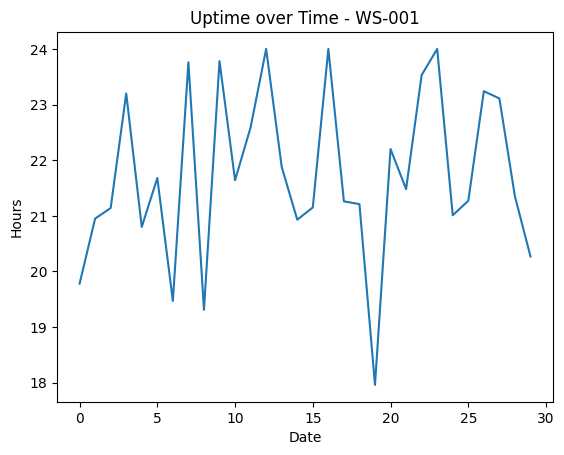

In [43]:
df = df.sort_index()
ws1 = df[df["hostname"] == "WS-001"]
ws1["uptime_hours"].plot(kind="line",title="Uptime over Time - WS-001")
plt.xlabel("Date")
plt.ylabel("Hours")
plt.show()

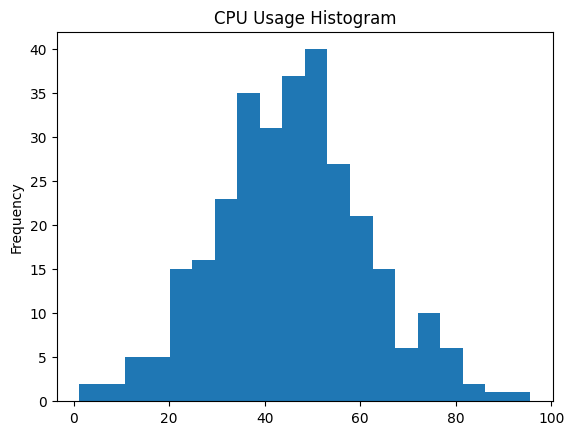

In [44]:
df["cpu_usage_percent"].plot(kind="hist",bins=20,title="CPU Usage Histogram")
plt.show()

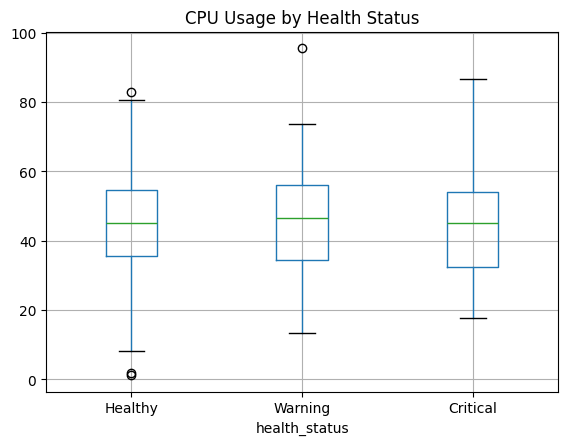

In [49]:
df.boxplot(column="cpu_usage_percent",by="health_status")
plt.suptitle("")
plt.title("CPU Usage by Health Status")
plt.show()

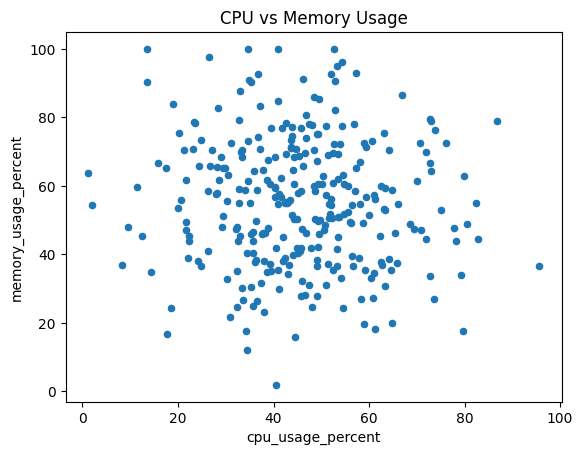

In [50]:
df.plot(kind="scatter", x="cpu_usage_percent", y="memory_usage_percent",
        title="CPU vs Memory Usage")
plt.show()

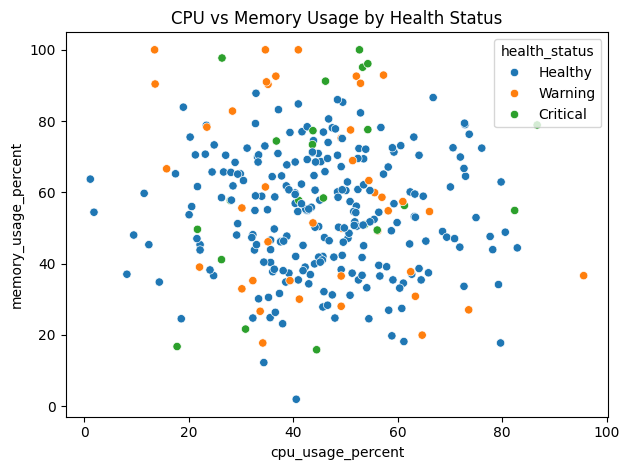

In [52]:
sns.scatterplot(data=df,x="cpu_usage_percent", y="memory_usage_percent",
                hue="health_status")
plt.title("CPU vs Memory Usage by Health Status")
plt.tight_layout()
plt.show()

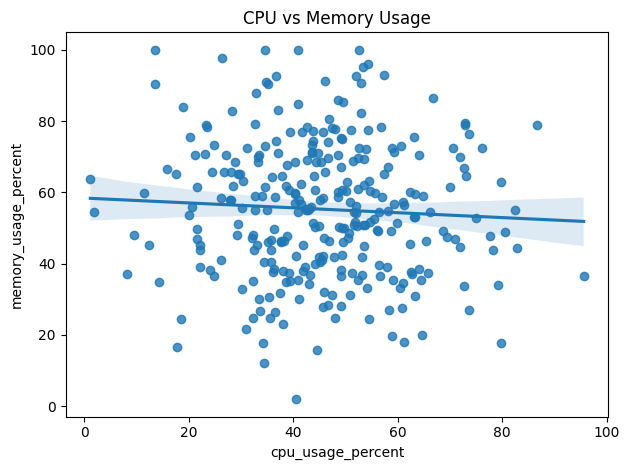

In [53]:
sns.regplot(data=df,x="cpu_usage_percent", y="memory_usage_percent")
plt.title("CPU vs Memory Usage")
plt.tight_layout()
plt.show()

/tmp/ipython-input-4079769550.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  avg_cpu = df.groupby("health_status")["cpu_usage_percent"].mean()


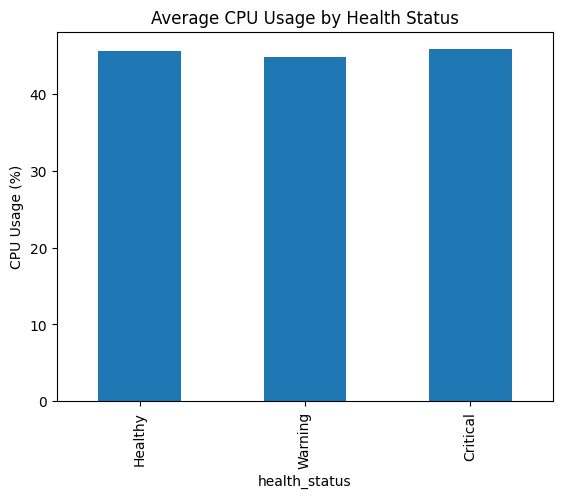

In [54]:
avg_cpu = df.groupby("health_status")["cpu_usage_percent"].mean()
avg_cpu.plot(kind="bar",title="Average CPU Usage by Health Status")
plt.ylabel("CPU Usage (%)")
plt.show()

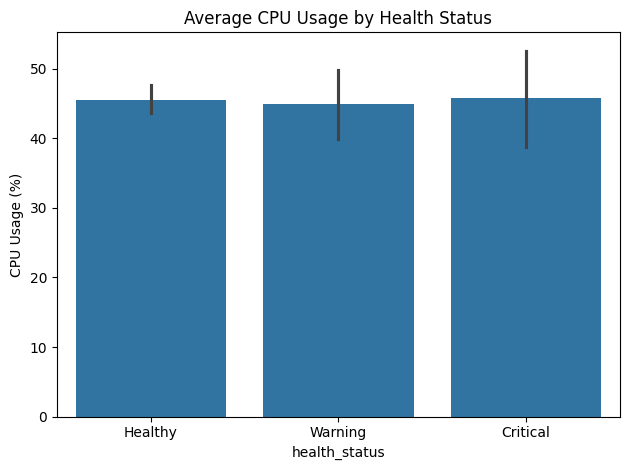

In [56]:
sns.barplot(data=df, x="health_status", y="cpu_usage_percent", estimator="mean")
plt.title("Average CPU Usage by Health Status")
plt.ylabel("CPU Usage (%)")
plt.tight_layout()
plt.show()

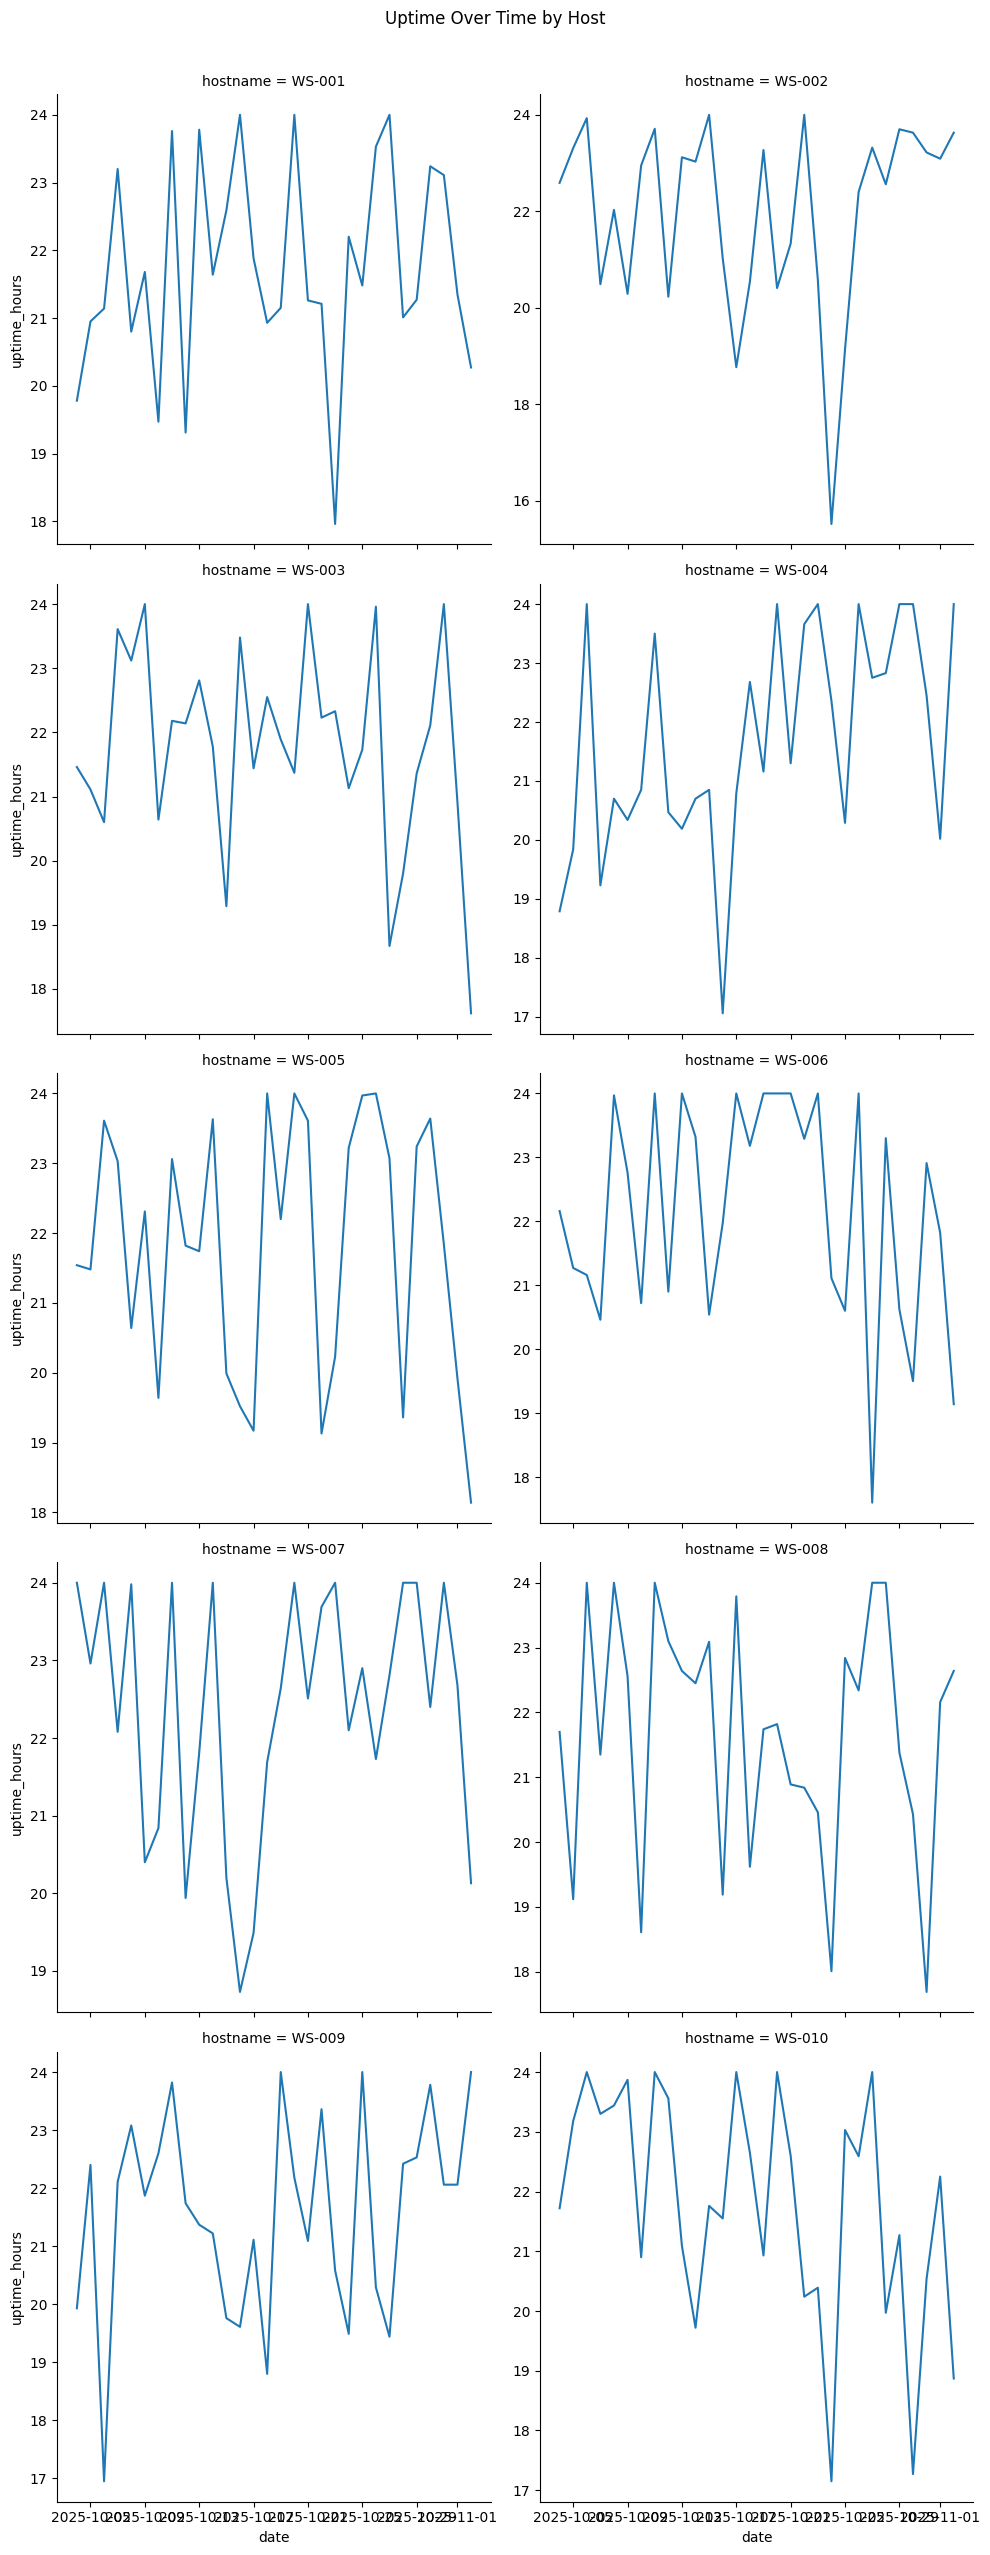

In [57]:
grid = sns.relplot(data=df.reset_index(), x="date", y="uptime_hours",
                   col="hostname", kind="line", col_wrap=2,facet_kws=dict(sharey=False))
                                                                          #sharey=False means donot allow to share y axis
grid.fig.suptitle("Uptime Over Time by Host", y=1.02)
plt.show()

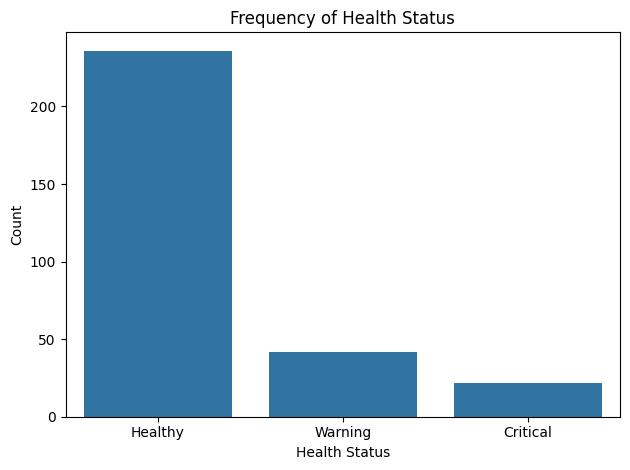

In [60]:
sns.countplot(data=df, x="health_status")
plt.title("Frequency of Health Status")
plt.xlabel("Health Status")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

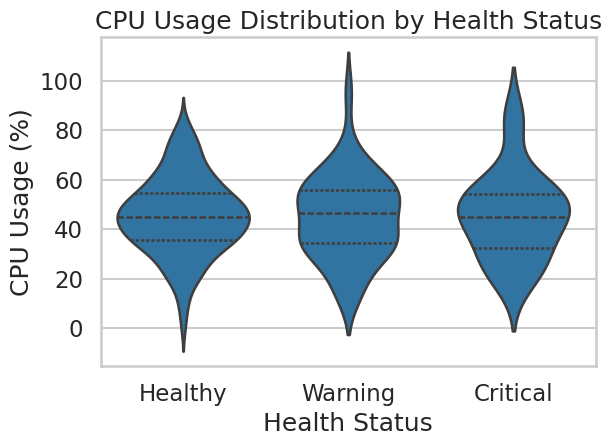

In [63]:
sns.set_style("whitegrid")
sns.set_context("talk")
sns.violinplot(data=df, x="health_status", y="cpu_usage_percent", inner="quartile")
plt.title("CPU Usage Distribution by Health Status")
plt.xlabel("Health Status")
plt.ylabel("CPU Usage (%)")
plt.tight_layout()
plt.show()

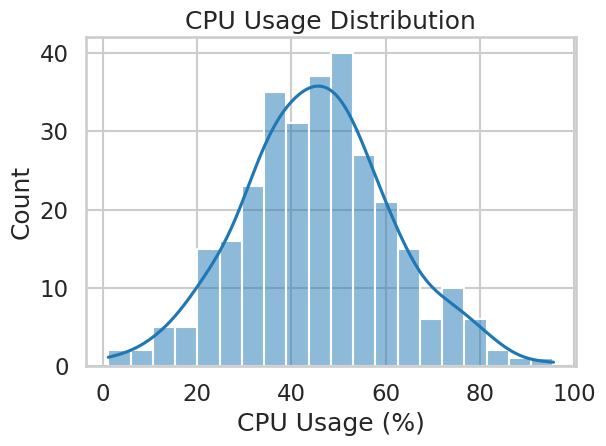

In [70]:
sns.histplot(data=df, x="cpu_usage_percent", bins=20, kde=True) #kde is the curve above the histogram ie kernel density
plt.title("CPU Usage Distribution")
plt.xlabel("CPU Usage (%)")
plt.tight_layout()
plt.savefig("CPU_Usage_Distribution_SmallDataset.png",dpi=150) #dpi= dots per inch
plt.show()

# **Advance**

In [72]:
import pandas as pd
import json
import sqlite3

In [ ]:
df = pd.read_csv("/content/smallDataset.txt",parse_dates=["date"])
status_order = ["Healthy","Warning","Critical"]
df['health_status'] = pd.Categorical(df["health_status"], categories = status_order, ordered=True)

In [76]:
json_sample = """
[
  {"name": "Server1", "cpu": 67},
  {"name": "Server2", "cpu": 45}
]
"""
json_data = pd.read_json(json_sample)
json_data

/tmp/ipython-input-87126387.py:7: FutureWarning: Passing literal json to 'read_json' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  json_data = pd.read_json(json_sample)


,name,cpu
0,Server1,67
1,Server2,45


In [81]:
mini = pd.DataFrame({"x":[1,2,3],"y":[10,20,30]})
mini.to_stata("data/mini_demo.dta")
stata_demo = pd.read_stata("data/mini_demo.dta")
stata_demo

,index,x,y
0,0,1,10
1,1,2,20
2,2,3,30


In [83]:
mini = pd.DataFrame({
    "hostname": ["WS-001","WS-002","WS-003"],
    "cpu_usage": [55,62,73]
})
conn = sqlite3.connect("data/demo.db")
mini.to_sql("systems", conn, if_exists="replace", index=False)
df_sql= pd.read_sql("SELECT * FROM systems", conn)
conn.close()
df_sql

,hostname,cpu_usage
0,WS-001,55
1,WS-002,62
2,WS-003,73


In [90]:
simplifiedDF = df[["date","hostname","os","health_status","cpu_usage_percent"]].copy()
simplifiedDF.head()

,date,hostname,os,health_status,cpu_usage_percent
0,2025-10-04,WS-001,Windows 10,Warning,49.2
1,2025-10-05,WS-001,Windows 10,Healthy,59.3
2,2025-10-06,WS-001,Windows 10,Healthy,34.4
3,2025-10-07,WS-001,Windows 10,Healthy,50.9
4,2025-10-08,WS-001,Windows 10,Healthy,49.4


In [92]:
simplifiedDF.isna().sum()

,0
date,0
hostname,0
os,0
health_status,0
cpu_usage_percent,0


In [93]:
q1= simplifiedDF["cpu_usage_percent"].quantile(0.01)
q99= simplifiedDF["cpu_usage_percent"].quantile(0.99)
simplifiedDF["cpu_usage_percent"]= simplifiedDF["cpu_usage_percent"].clip(q1,q99)

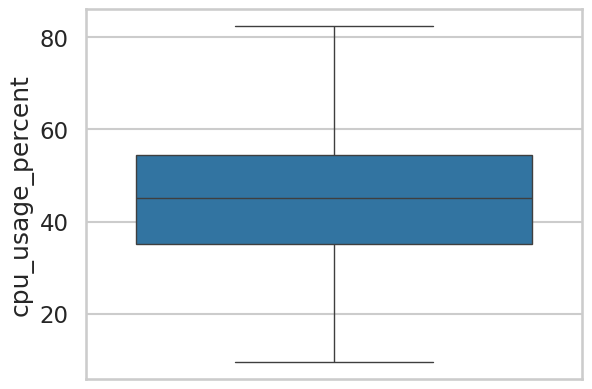

In [95]:
sns.boxplot(data=simplifiedDF, y="cpu_usage_percent")
plt.show()

In [96]:
def categorize_cpu(x):
  if x < 30:
    return "Low"
  elif x < 60:
    return "Medium"
  elif x < 85:
    return "High"
  else:
    return "Very High"

simplifiedDF["cpu_level"] = simplifiedDF["cpu_usage_percent"].apply(categorize_cpu)
print(simplifiedDF["cpu_level"].value_counts())

cpu_level
Medium    203
High       51
Low        46
Name: count, dtype: int64


In [97]:
simplifiedDF["cpu_squared"] = simplifiedDF["cpu_usage_percent"].apply(lambda x: x**2)
simplifiedDF[["cpu_squared"]].head()

,cpu_squared
0,2420.64
1,3516.49
2,1183.36
3,2590.81
4,2440.36


In [98]:
host_metadata = pd.DataFrame({
    "hostname": ["WS-001","WS-002","WS-003","WS-004"],
    "department": ["Finance","HR","Engineering","IT Support"],
    "machine_type": ["Workstation","Laptop","Workstation","Virtual Machine"]
})
host_metadata

,hostname,department,machine_type
0,WS-001,Finance,Workstation
1,WS-002,HR,Laptop
2,WS-003,Engineering,Workstation
3,WS-004,IT Support,Virtual Machine


In [99]:
mergedDF = simplifiedDF.merge(host_metadata, on="hostname",how="left")
mergedDF.head()

,date,hostname,os,health_status,cpu_usage_percent,cpu_level,cpu_squared,department,machine_type
0,2025-10-04,WS-001,Windows 10,Warning,49.2,Medium,2420.64,Finance,Workstation
1,2025-10-05,WS-001,Windows 10,Healthy,59.3,Medium,3516.49,Finance,Workstation
2,2025-10-06,WS-001,Windows 10,Healthy,34.4,Medium,1183.36,Finance,Workstation
3,2025-10-07,WS-001,Windows 10,Healthy,50.9,Medium,2590.81,Finance,Workstation
4,2025-10-08,WS-001,Windows 10,Healthy,49.4,Medium,2440.36,Finance,Workstation


In [101]:
longDF = pd.melt(df,
                 id_vars= ["date","hostname"],
                 value_vars= ["cpu_usage_percent","disk_free_gb"],
                 var_name= "metric",
                 value_name= "value")
longDF.head()

,date,hostname,metric,value
0,2025-10-04,WS-001,cpu_usage_percent,49.2
1,2025-10-05,WS-001,cpu_usage_percent,59.3
2,2025-10-06,WS-001,cpu_usage_percent,34.4
3,2025-10-07,WS-001,cpu_usage_percent,50.9
4,2025-10-08,WS-001,cpu_usage_percent,49.4


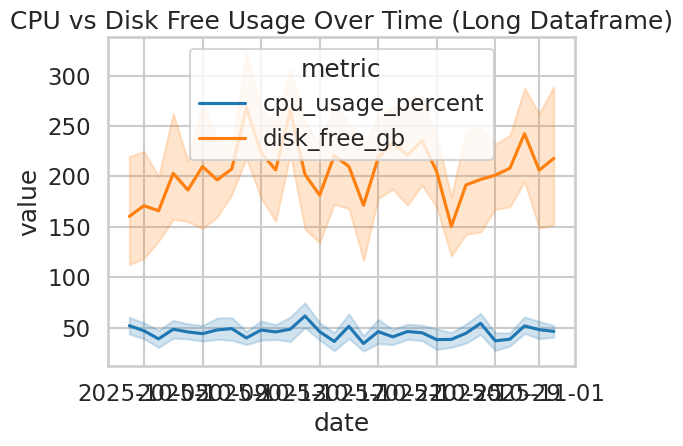

In [103]:
sns.lineplot(data=longDF, x="date", y="value", hue="metric")
plt.title("CPU vs Disk Free Usage Over Time (Long Dataframe)")
plt.tight_layout()
plt.show()

In [104]:
grouped = df.groupby("health_status")[["cpu_usage_percent","memory_usage_percent"]].mean()
grouped

/tmp/ipython-input-3908890458.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df.groupby("health_status")[["cpu_usage_percent","memory_usage_percent"]].mean()


,cpu_usage_percent,memory_usage_percent
health_status,,
Healthy,45.575000,53.823729
Warning,44.864286,59.169048
Critical,45.809091,63.263636


In [105]:
pivot_table = mergedDF.pivot_table(values="cpu_usage_percent", index="department",
                                   columns="health_status", aggfunc="mean", fill_value=0)
pivot_table

/tmp/ipython-input-1132722540.py:1: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot_table = mergedDF.pivot_table(values="cpu_usage_percent", index="department",


health_status,Healthy,Warning,Critical
department,,,
Engineering,44.427480,37.750000,17.8000
Finance,45.624000,65.901667,55.2025
HR,47.604545,39.640000,46.8000
IT Support,40.052000,54.400000,53.7000


In [106]:
tsDF = df.copy() #ts- time series
tsDF["date"] = pd.to_datetime(tsDF["date"])
tsDF = tsDF.set_index("date").sort_index()
tsDF.head()

,hostname,os,uptime_hours,adobe_runtime_minutes,cpu_usage_percent,memory_usage_percent,disk_free_gb,health_status,ticket_opened
date,,,,,,,,,
2025-10-04,WS-001,Windows 10,19.78,199.1,49.2,75.2,153.5,Warning,False
2025-10-04,WS-005,Windows 10,21.54,217.7,64.1,38.6,79.8,Healthy,False
2025-10-04,WS-009,Windows 10,19.93,258.8,45.8,58.4,182.0,Critical,False
2025-10-04,WS-008,Windows 10,21.70,187.5,42.4,55.3,112.3,Healthy,False
2025-10-04,WS-006,Windows 10,22.16,243.9,37.2,83.2,383.9,Healthy,False


In [107]:
daily_cpu = tsDF["cpu_usage_percent"].resample("D").mean() #Resample means changing the frequency of your data
daily_cpu.head()

,cpu_usage_percent
date,
2025-10-04,52.14
2025-10-05,47.11
2025-10-06,39.07
2025-10-07,48.60
2025-10-08,45.93


In [108]:
full_range = pd.date_range(start=daily_cpu.index.min(), end=daily_cpu.index.max())
ts_reindexed = daily_cpu.reindex(full_range)
ts_reindexed.head() #Reindex means changing the labels (index) of your data

,cpu_usage_percent
2025-10-04,52.14
2025-10-05,47.11
2025-10-06,39.07
2025-10-07,48.60
2025-10-08,45.93


In [109]:
print(daily_cpu.index.max())

2025-11-02 00:00:00


In [111]:
tsDF["cpu_roll_7"] = tsDF["cpu_usage_percent"].rolling(7).mean() #rolling creates a window of 7 values and
                                                                 #then mean of those 7 values is taken
tsDF[["cpu_usage_percent","cpu_roll_7"]].head(15)

,cpu_usage_percent,cpu_roll_7
date,,
2025-10-04,49.2,NaN
2025-10-04,64.1,NaN
2025-10-04,45.8,NaN
2025-10-04,42.4,NaN
2025-10-04,37.2,NaN
2025-10-04,41.9,NaN
2025-10-04,60.4,48.714286
2025-10-04,73.0,52.114286
2025-10-04,73.7,53.485714


In [112]:
tsDF["cpu_over_80"] = tsDF["cpu_usage_percent"] > 50
tsDF["high_cpu-running_total"] = tsDF["cpu_over_80"].cumsum()
tsDF[["cpu_usage_percent","cpu_over_80","high_cpu-running_total"]].head(20)

,cpu_usage_percent,cpu_over_80,high_cpu-running_total
date,,,
2025-10-04,49.2,False,0
2025-10-04,64.1,True,1
2025-10-04,45.8,False,1
2025-10-04,42.4,False,1
2025-10-04,37.2,False,1
2025-10-04,41.9,False,1
2025-10-04,60.4,True,2
2025-10-04,73.0,True,3
2025-10-04,73.7,True,4


In [113]:
corr_matrix = simplifiedDF.corr(numeric_only=True)
corr_matrix

,cpu_usage_percent,cpu_squared
cpu_usage_percent,1.000000,0.975311
cpu_squared,0.975311,1.000000


In [114]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

x = df[["disk_free_gb"]]
y = df[["cpu_usage_percent"]]

x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.2,random_state=42)
lin_model= LinearRegression()
lin_model.fit(x_train,y_train)
r2_score = lin_model.score(x_test,y_test)
print(r2_score) #measures how well a regression model fits the data

-0.008599541398963462


<Axes: xlabel='disk_free_gb', ylabel='cpu_usage_percent'>

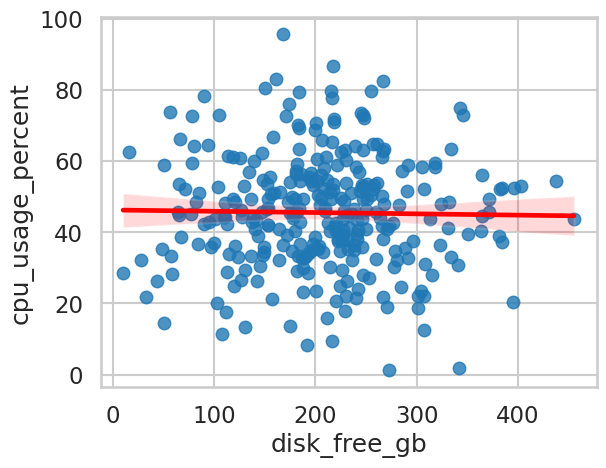

In [115]:
sns.regplot(data=df, x="disk_free_gb", y="cpu_usage_percent",line_kws={"color":"red"})

In [116]:
cars = pd.DataFrame({
    "mpg": [21,22,18,30,27,24],
    "weight": [2.6,2.9,3.2,2.0,2.2,2.5],
    "horsepower": [110,115,130,95,88,100],
    "origin": ["US","US","US","EU","EU","JP"]
})
cars

,mpg,weight,horsepower,origin
0,21,2.6,110,US
1,22,2.9,115,US
2,18,3.2,130,US
3,30,2.0,95,EU
4,27,2.2,88,EU
5,24,2.5,100,JP


In [117]:
x_simple = cars[["weight"]]
y_cars = cars["mpg"]

x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.2,random_state=42)
model_simple= LinearRegression()
model_simple.fit(x_train,y_train)
simple_r2 = model_simple.score(x_test,y_test)
print(simple_r2)

-0.008599541398963462


In [118]:
x_multi = cars[["weight", "horsepower"]]

x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.3,random_state=42)
model_multi= LinearRegression()
model_multi.fit(x_train,y_train)
multi_r2 = model_multi.score(x_test,y_test)
print(multi_r2)

-0.03255357745096288


In [119]:
cars_encoded = pd.get_dummies(cars, columns=["origin"], drop_first=True)
cars_encoded

,mpg,weight,horsepower,origin_JP,origin_US
0,21,2.6,110,False,True
1,22,2.9,115,False,True
2,18,3.2,130,False,True
3,30,2.0,95,False,False
4,27,2.2,88,False,False
5,24,2.5,100,True,False
